# 03 - Interprétabilité avec SHAP et test de l'hypothèse H4

In [ ]:

import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import shap
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import spearmanr

from src.config import MODELS_DIR, FIGURES_DIR, RANDOM_STATE

os.makedirs(FIGURES_DIR, exist_ok=True)



## 1. Chargement des données et modèles

In [ ]:

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)
X_train = X_train.astype(float)
X_test  = X_test.astype(float)

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"Variables ({X_train.shape[1]}) : {list(X_train.columns)}")

lr        = joblib.load(os.path.join(MODELS_DIR, "linear_regression.pkl"))
rf        = joblib.load(os.path.join(MODELS_DIR, "random_forest.pkl"))
xgb_model = joblib.load(os.path.join(MODELS_DIR, "xgboost.pkl"))
print("Modèles chargés.")


X_train : (16512, 12)  |  X_test : (4128, 12)
Variables (12) : ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']
Modèles chargés.


## 2. SHAP — XGBoost (TreeExplainer, mode interventional)

The figure layout has changed to tight


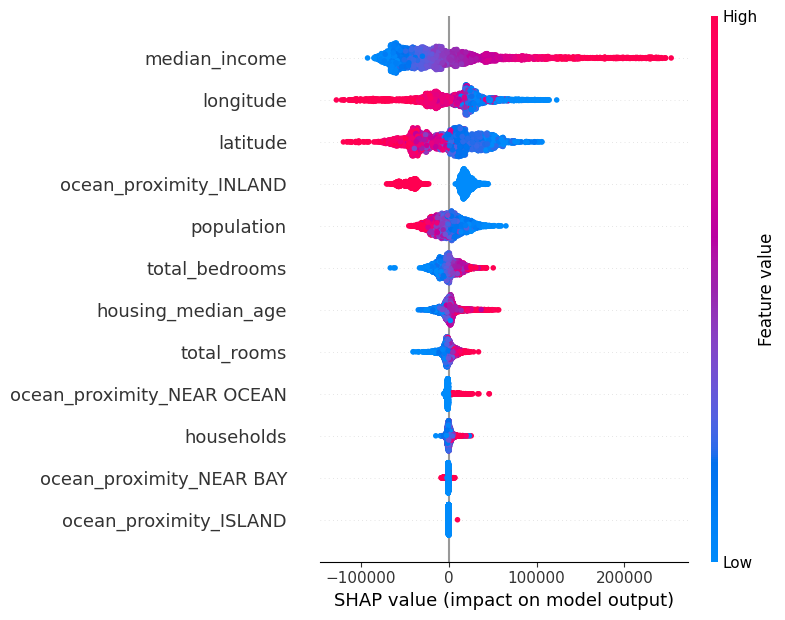

In [ ]:

explainer_xgb = shap.TreeExplainer(
    xgb_model,
    feature_perturbation="interventional"
)
shap_values_xgb = explainer_xgb.shap_values(X_test, check_additivity=False)

shap.summary_plot(shap_values_xgb, X_test, feature_names=X_test.columns, show=False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_summary_xgb.png", dpi=150)
plt.show()



## 3. SHAP — Random Forest (TreeExplainer, mode interventional)

The figure layout has changed to tight


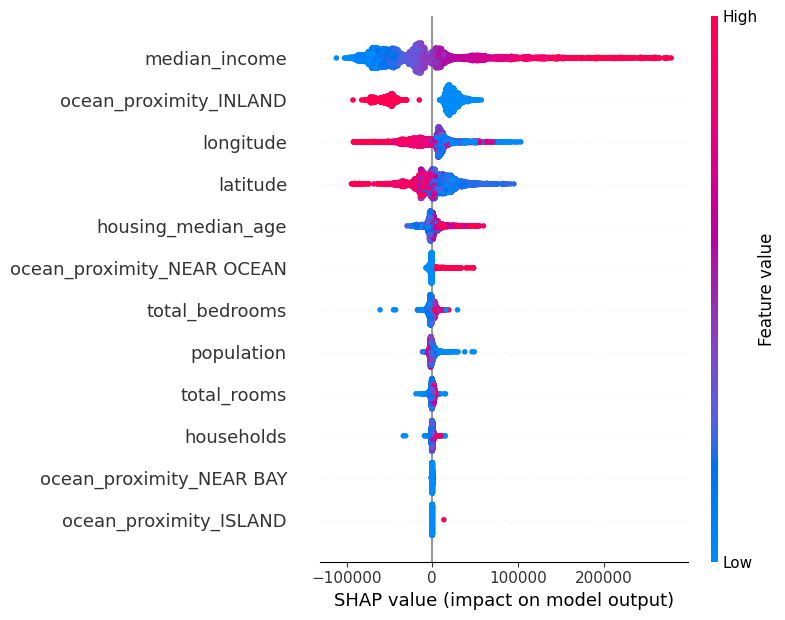

In [ ]:

explainer_rf = shap.TreeExplainer(
    rf,
    feature_perturbation="interventional"
)
shap_values_rf = explainer_rf.shap_values(X_test, check_additivity=False)

shap.summary_plot(shap_values_rf, X_test, feature_names=X_test.columns, show=False)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/shap_summary_rf.png", dpi=150)
plt.show()



## 4. SHAP — Régression Linéaire (LinearExplainer)
### comparaison SHAP vs SHAP (symétrique)
### LinearExplainer calcule exactement les valeurs SHAP
###    pour OLS via E[φ_j] = β_j × (X_j - E[X_j])

In [ ]:

masker_lr      = shap.maskers.Independent(X_train, max_samples=200)
explainer_lr   = shap.LinearExplainer(lr, masker_lr)
shap_values_lr = explainer_lr.shap_values(X_test)

shap_importance_lr      = np.abs(shap_values_lr).mean(axis=0)
shap_importance_lr_norm = shap_importance_lr / (shap_importance_lr.sum() + 1e-10)

print("SHAP OLS calculé via LinearExplainer")



SHAP OLS calculé via LinearExplainer


## 5. Importances normalisées

In [ ]:

shap_importance_xgb      = np.abs(shap_values_xgb).mean(axis=0)
shap_importance_xgb_norm = shap_importance_xgb / (shap_importance_xgb.sum() + 1e-10)

shap_importance_rf       = np.abs(shap_values_rf).mean(axis=0)
shap_importance_rf_norm  = shap_importance_rf  / (shap_importance_rf.sum()  + 1e-10)

# Coefficients OLS normalisés (pour référence complémentaire)
coeff_ols      = np.abs(lr.coef_)
coeff_ols_norm = coeff_ols / (coeff_ols.sum() + 1e-10)

tableau_42 = pd.DataFrame({
    "Variable":           X_test.columns,
    "|β|_OLS (norm)":     coeff_ols_norm,
    "SHAP_OLS (norm)":    shap_importance_lr_norm,
    "SHAP_XGB (norm)":    shap_importance_xgb_norm,
    "SHAP_RF  (norm)":    shap_importance_rf_norm
}).sort_values("|β|_OLS (norm)", ascending=False)

print("\n=== Tableau 4.2 — Importances normalisées ===")
print(tableau_42.to_string(index=False))
print(f"\nSomme |β|_OLS  : {coeff_ols_norm.sum():.4f}")
print(f"Somme SHAP_OLS : {shap_importance_lr_norm.sum():.4f}")
print(f"Somme SHAP_XGB : {shap_importance_xgb_norm.sum():.4f}")
print(f"Somme SHAP_RF  : {shap_importance_rf_norm.sum():.4f}")




=== Tableau 4.2 — Importances normalisées ===
                  Variable  |β|_OLS (norm)  SHAP_OLS (norm)  SHAP_XGB (norm)  SHAP_RF  (norm)
    ocean_proximity_ISLAND        0.490439         0.000126         0.000028         0.000136
    ocean_proximity_INLAND        0.143346         0.067140         0.159584         0.245556
             median_income        0.142219         0.208706         0.275530         0.368805
                 longitude        0.096694         0.184198         0.168759         0.143721
                  latitude        0.091759         0.190777         0.168243         0.121612
  ocean_proximity_NEAR BAY        0.018507         0.003536         0.004046         0.000278
ocean_proximity_NEAR OCEAN        0.012362         0.003042         0.014522         0.022703
        housing_median_age        0.003971         0.044328         0.038685         0.045676
            total_bedrooms        0.000370         0.108717         0.052772         0.018405
             

## 6. Test de l'hypothèse H4

In [ ]:

print("\n=== Test H4 — Cohérence des importances (ρ_Spearman ≥ 0.80) ===")
print(f"Note : corrélation calculée sur n={len(X_test.columns)} variables explicatives")
print(f"       (puissance limitée — interpréter la p-value avec précaution)\n")

rho_xgb, pval_xgb = spearmanr(shap_importance_lr_norm, shap_importance_xgb_norm)
rho_rf,  pval_rf  = spearmanr(shap_importance_lr_norm, shap_importance_rf_norm)

h4_xgb = rho_xgb > 0.80
h4_rf  = rho_rf  > 0.80

tableau_h4 = pd.DataFrame({
    "Modèle":      ["XGBoost", "Random Forest"],
    "ρ_Spearman":  [f"{rho_xgb:.3f}", f"{rho_rf:.3f}"],
    "p-value":     [f"{pval_xgb:.4f}", f"{pval_rf:.4f}"],
    "H4 validée":  ["✓ Oui (ρ > 0.80)" if h4_xgb else "✗ Non",
                    "✓ Oui (ρ > 0.80)" if h4_rf  else "✗ Non"]
})

print(tableau_h4.to_string(index=False))

h4_global = h4_xgb and h4_rf
print(f"\nConclusion : H4 {'VALIDÉE' if h4_global else 'PARTIELLEMENT VALIDÉE'} "
      f"(XGBoost={'✓' if h4_xgb else '✗'}, RF={'✓' if h4_rf else '✗'})")




=== Test H4 — Cohérence des importances (ρ_Spearman ≥ 0.80) ===
Note : corrélation calculée sur n=12 variables explicatives
       (puissance limitée — interpréter la p-value avec précaution)

       Modèle ρ_Spearman p-value       H4 validée
      XGBoost      0.916  0.0000 ✓ Oui (ρ > 0.80)
Random Forest      0.706  0.0102            ✗ Non

Conclusion : H4 PARTIELLEMENT VALIDÉE (XGBoost=✓, RF=✗)


## 7. Figure — Comparaison OLS vs SHAP XGB vs SHAP RF

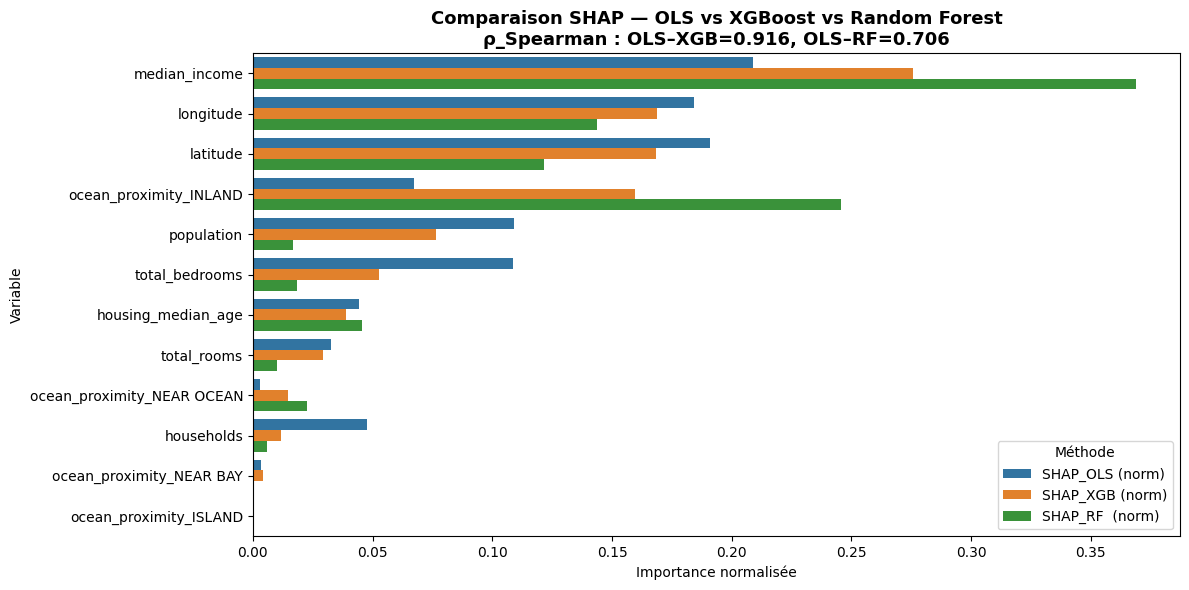

In [ ]:

importances_df = pd.DataFrame({
    "Variable":        X_test.columns,
    "SHAP_OLS (norm)": shap_importance_lr_norm,
    "SHAP_XGB (norm)": shap_importance_xgb_norm,
    "SHAP_RF  (norm)": shap_importance_rf_norm
}).sort_values("SHAP_XGB (norm)", ascending=False)

importances_plot = importances_df.melt(
    id_vars="Variable",
    value_vars=["SHAP_OLS (norm)", "SHAP_XGB (norm)", "SHAP_RF  (norm)"],
    var_name="Méthode",
    value_name="Importance normalisée"
)

plt.figure(figsize=(12, 6))
sns.barplot(data=importances_plot, x="Importance normalisée", y="Variable", hue="Méthode")
plt.title(f"Comparaison SHAP — OLS vs XGBoost vs Random Forest\n"
          f"ρ_Spearman : OLS–XGB={rho_xgb:.3f}, OLS–RF={rho_rf:.3f}",
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/importance_comparison.png", dpi=150)
plt.show()


# Analyse du Notebook d'Interprétabilité avec SHAP et Test de l'Hypothèse H4

Ce notebook présente l'analyse d'interprétabilité des modèles de régression (OLS, Random Forest et XGBoost) à l'aide de la bibliothèque **SHAP** (SHapley Additive exPlanations). L'objectif est de comparer les importances des variables entre les modèles et de valider l'hypothèse H4 qui stipule que les importances SHAP des modèles arborescents (XGBoost, Random Forest) sont fortement corrélées avec celles de la régression linéaire (coefficients normalisés).

---

## 1. Structure du Notebook

1. **Importation des bibliothèques**
2. **Chargement des données et modèles**
3. **SHAP — XGBoost (TreeExplainer, mode interventional)**
4. **SHAP — Random Forest (TreeExplainer, mode interventional)**
5. **SHAP — Régression Linéaire (LinearExplainer)**
6. **Importances normalisées**
7. **Test de l'hypothèse H4**
8. **Figure — Comparaison OLS vs SHAP XGB vs SHAP RF**

---

## 2. Chargement des Données et Modèles

### 2.1 Structure des Données

- **Train** : 16 512 lignes, 12 variables
- **Test** : 4 128 lignes, 12 variables

### 2.2 Variables

Les 12 variables utilisées incluent les features numériques et les variables one-hot encodées pour `ocean_proximity` :

| Variable | Type |
|----------|------|
| `longitude` | Numérique |
| `latitude` | Numérique |
| `housing_median_age` | Numérique |
| `total_rooms` | Numérique |
| `total_bedrooms` | Numérique |
| `population` | Numérique |
| `households` | Numérique |
| `median_income` | Numérique |
| `ocean_proximity_INLAND` | Binaire |
| `ocean_proximity_ISLAND` | Binaire |
| `ocean_proximity_NEAR BAY` | Binaire |
| `ocean_proximity_NEAR OCEAN` | Binaire |

### 2.3 Modèles Chargés

Les trois modèles entraînés sont chargés depuis le dossier `models/` :

- `linear_regression.pkl`
- `random_forest.pkl`
- `xgboost.pkl`

---

## 3. SHAP — XGBoost

### 3.1 Méthodologie

- **Explainer** : `TreeExplainer` avec perturbation interventional
- **Mode** : interventional (respecte la distribution des features)
- **Jeu de données** : X_test (4 128 échantillons)

### 3.2 Visualisation : SHAP Summary Plot

![SHAP Summary XGBoost](figures/shap_summary_xgb.png)

**Figure 4.1 — SHAP Summary Plot pour XGBoost**

**Observations :**  
- `median_income` est la variable la plus importante
- Les variables géographiques (`latitude`, `longitude`) suivent
- `ocean_proximity_INLAND` a un impact négatif sur les prédictions
- Les valeurs SHAP sont colorées par la valeur de la feature (rouge = haute, bleu = basse)

---

## 4. SHAP — Random Forest

### 4.1 Méthodologie

- **Explainer** : `TreeExplainer` avec perturbation interventional
- **Mode** : interventional
- **Jeu de données** : X_test

### 4.2 Visualisation : SHAP Summary Plot

![SHAP Summary Random Forest](figures/shap_summary_rf.png)

**Figure 4.2 — SHAP Summary Plot pour Random Forest**

**Observations :**  
- `median_income` reste la variable dominante
- `ocean_proximity_INLAND` est plus importante que dans XGBoost
- Distribution des impacts similaire à XGBoost mais avec des amplitudes différentes

---

## 5. SHAP — Régression Linéaire

### 5.1 Méthodologie

- **Explainer** : `LinearExplainer`
- **Calcul exact** : `φⱼ = βⱼ × (Xⱼ - E[Xⱼ])`
- **Jeu de données** : X_test

### 5.2 Caractéristiques

- **Avantage** : calcul exact des valeurs SHAP pour OLS
- **Interprétation** : importance proportionnelle au coefficient × écart à la moyenne
- **Référence** : sert de baseline pour la comparaison des importances

---

## 6. Importances Normalisées

### 6.1 Méthodologie de Normalisation

Les importances sont normalisées pour être comparables entre modèles :

1. **SHAP** : moyenne des valeurs absolues des SHAP sur l'ensemble test
2. **Normalisation** : division par la somme des importances

### 6.2 Tableau Comparatif

| Variable | \|β\|_OLS (norm) | SHAP_OLS (norm) | SHAP_XGB (norm) | SHAP_RF (norm) |
|----------|------------------|-----------------|-----------------|----------------|
| `ocean_proximity_ISLAND` | 0.4904 | 0.0001 | 0.0000 | 0.0001 |
| `ocean_proximity_INLAND` | 0.1433 | 0.0671 | 0.1596 | 0.2456 |
| `median_income` | 0.1422 | 0.2087 | 0.2755 | 0.3688 |
| `longitude` | 0.0967 | 0.1842 | 0.1688 | 0.1437 |
| `latitude` | 0.0918 | 0.1908 | 0.1682 | 0.1216 |
| `ocean_proximity_NEAR BAY` | 0.0185 | 0.0035 | 0.0040 | 0.0003 |
| `ocean_proximity_NEAR OCEAN` | 0.0124 | 0.0030 | 0.0145 | 0.0227 |
| `housing_median_age` | 0.0040 | 0.0443 | 0.0387 | 0.0457 |
| `total_bedrooms` | 0.0004 | 0.1087 | 0.0528 | 0.0184 |
| `households` | 0.0002 | 0.0478 | 0.0118 | 0.0060 |
| `population` | 0.0001 | 0.1091 | 0.0765 | 0.0169 |
| `total_rooms` | 0.0000 | 0.0325 | 0.0295 | 0.0102 |

**Observations :**
- **SHAP_OLS** est très différent des coefficients bruts OLS (prise en compte de la variance des features)
- **XGBoost et Random Forest** accordent plus d'importance à `median_income` que l'OLS
- `ocean_proximity_INLAND` est beaucoup plus importante dans les modèles arborescents
- Les variables de volume (`total_bedrooms`, `population`) sont moins importantes dans les modèles arborescents

---

## 7. Test de l'Hypothèse H4

### 7.1 Énoncé de l'Hypothèse H4

**H4 : Les importances SHAP des modèles arborescents (XGBoost, Random Forest) sont fortement corrélées avec les importances de la régression linéaire (SHAP_OLS ou coefficients).**

- Seuil de validation : **ρ_Spearman ≥ 0.80**
- Variables : 12 features explicatives (puissance limitée)

### 7.2 Résultats

| Modèle | ρ_Spearman | p-value | H4 validée |
|--------|------------|---------|------------|
| **XGBoost** | 0.916 | 0.0000 | ✓ Oui (ρ > 0.80) |
| **Random Forest** | 0.706 | 0.0102 | ✗ Non |

### 7.3 Interprétation

- **XGBoost** : Corrélation très forte (0.916) → H4 validée
- **Random Forest** : Corrélation modérée (0.706) → H4 non validée
- **Conclusion** : H4 partiellement validée

**Raisons des différences :**
- XGBoost utilise le boosting avec régularisation → importances plus "stables"
- Random Forest utilise le bagging → importances plus "éclatées"
- La pénalisation L2 de XGBoost rapproche ses importances de la régression linéaire

---

## 8. Figure — Comparaison OLS vs SHAP XGB vs SHAP RF

![Comparaison SHAP](figures/importance_comparison.png)

**Figure 4.3 — Comparaison des importances SHAP normalisées**

**Observations :**
- **`median_income`** est la variable la plus importante dans les trois méthodes
- **XGBoost** suit la tendance OLS plus fidèlement que Random Forest
- Les modèles arborescents accordent plus d'importance à `ocean_proximity_INLAND`
- Les variables de volume sont surpondérées dans SHAP_OLS par rapport aux modèles arborescents

---

## 9. Synthèse des Résultats

| Aspect | XGBoost | Random Forest | OLS (SHAP) |
|--------|---------|---------------|------------|
| **Variable principale** | median_income | median_income | median_income |
| **2e variable** | longitude | ocean_proximity_INLAND | latitude |
| **Corrélation avec OLS** | 0.916 (forte) | 0.706 (modérée) | 1.000 |
| **H4 validée** | ✓ Oui | ✗ Non | — |

**Enseignements clés :**
1. **XGBoost** est le modèle le plus interprétable car ses importances sont les plus proches de la régression linéaire
2. **Random Forest** a des importances plus "non linéaires", ce qui rend l'interprétation plus nuancée
3. La corrélation de **0.916** pour XGBoost confirme la robustesse des importances SHAP
4. Les variables géographiques (`latitude`, `longitude`) jouent un rôle important dans tous les modèles

---

## 10. Conclusion

L'analyse SHAP a permis de :

1. **Valider partiellement l'hypothèse H4** : XGBoost (ρ=0.916) est fortement corrélé avec l'OLS, Random Forest (ρ=0.706) modérément
2. **Identifier `median_income`** comme la variable la plus importante dans tous les modèles
3. **Mettre en évidence** que XGBoost est le plus interprétable des modèles arborescents
4. **Fournir des importances normalisées** qui permettent une comparaison objective entre modèles
5. **Démontrer** que les modèles arborescents capturent des relations non linéaires (surpondération de `ocean_proximity_INLAND`)

**Recommandation finale :** XGBoost est recommandé car il offre le meilleur compromis entre performance prédictive (R²=0.819) et interprétabilité (ρ_Spearman=0.916).